In [10]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from pathlib import Path

In [11]:
BASE_DIR = Path().resolve()
DATASET_DIR = BASE_DIR / "dataset"
MODELS_DIR = BASE_DIR / "models"

MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [12]:
data = pd.read_csv(DATASET_DIR / "Indian Liver Patient Dataset (ILPD).csv")
print(data)

     Age  Gender    TB   DB  Alkphos  Sgpt  Sgot   TP  ALB  A/G Ratio  \
0     65  Female   0.7  0.1      187    16    18  6.8  3.3       0.90   
1     62    Male  10.9  5.5      699    64   100  7.5  3.2       0.74   
2     62    Male   7.3  4.1      490    60    68  7.0  3.3       0.89   
3     58    Male   1.0  0.4      182    14    20  6.8  3.4       1.00   
4     72    Male   3.9  2.0      195    27    59  7.3  2.4       0.40   
..   ...     ...   ...  ...      ...   ...   ...  ...  ...        ...   
578   60    Male   0.5  0.1      500    20    34  5.9  1.6       0.37   
579   40    Male   0.6  0.1       98    35    31  6.0  3.2       1.10   
580   52    Male   0.8  0.2      245    48    49  6.4  3.2       1.00   
581   31    Male   1.3  0.5      184    29    32  6.8  3.4       1.00   
582   38    Male   1.0  0.3      216    21    24  7.3  4.4       1.50   

     Selector  
0           1  
1           1  
2           1  
3           1  
4           1  
..        ...  
578        

In [13]:
data["A/G Ratio"] = data["A/G Ratio"].fillna(data["A/G Ratio"].median())
print(data)

     Age  Gender    TB   DB  Alkphos  Sgpt  Sgot   TP  ALB  A/G Ratio  \
0     65  Female   0.7  0.1      187    16    18  6.8  3.3       0.90   
1     62    Male  10.9  5.5      699    64   100  7.5  3.2       0.74   
2     62    Male   7.3  4.1      490    60    68  7.0  3.3       0.89   
3     58    Male   1.0  0.4      182    14    20  6.8  3.4       1.00   
4     72    Male   3.9  2.0      195    27    59  7.3  2.4       0.40   
..   ...     ...   ...  ...      ...   ...   ...  ...  ...        ...   
578   60    Male   0.5  0.1      500    20    34  5.9  1.6       0.37   
579   40    Male   0.6  0.1       98    35    31  6.0  3.2       1.10   
580   52    Male   0.8  0.2      245    48    49  6.4  3.2       1.00   
581   31    Male   1.3  0.5      184    29    32  6.8  3.4       1.00   
582   38    Male   1.0  0.3      216    21    24  7.3  4.4       1.50   

     Selector  
0           1  
1           1  
2           1  
3           1  
4           1  
..        ...  
578        

In [14]:
X = data.drop(columns=["Selector"])
y = data["Selector"].replace({2: 0, 1: 1})

In [15]:
numeric_features = [
    "Age","TB","DB","Alkphos","Sgpt","Sgot","TP","ALB","A/G Ratio"
]
categorical_features = ["Gender"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=300, random_state=42))
])

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'TB', 'DB', 'Alkphos',
                                                   'Sgpt', 'Sgot', 'TP', 'ALB',
                                                   'A/G Ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [17]:
pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
print("Liver Accuracy:", acc)

Liver Accuracy: 0.7264957264957265


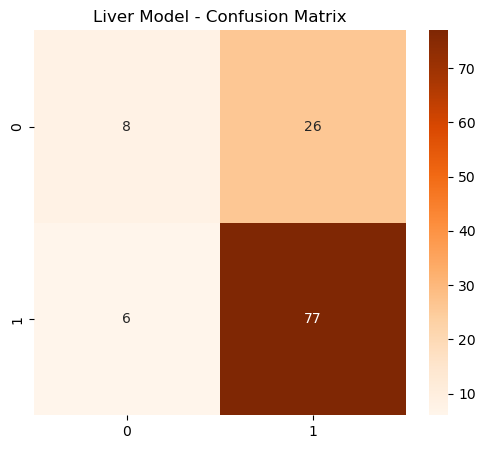

In [18]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Liver Model - Confusion Matrix")
plt.show()

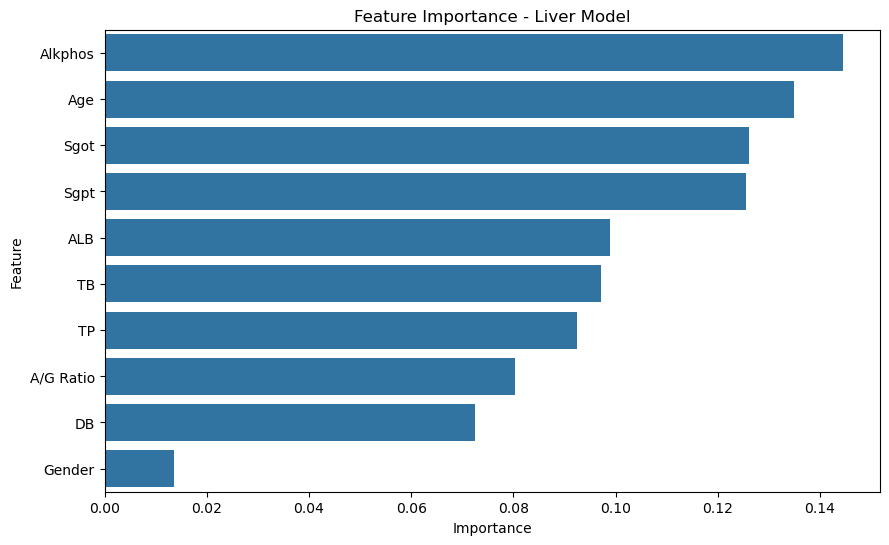

In [20]:
rf_model = model.named_steps["classifier"]

feature_importance = rf_model.feature_importances_

# IMPORTANT: after encoding, feature names change
# simple version (approximate)
features = numeric_features + categorical_features

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance[:len(features)]
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance - Liver Model")
plt.show()

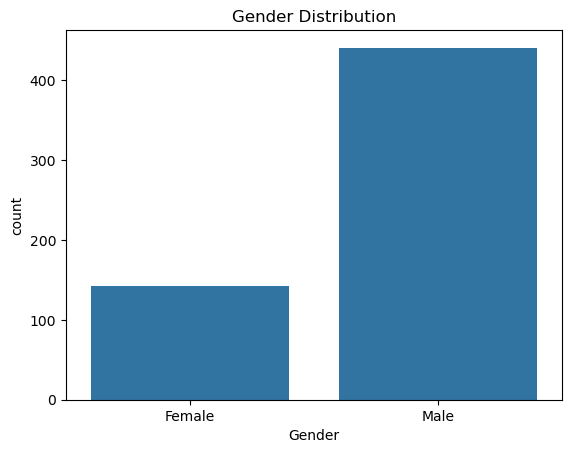

In [21]:
sns.countplot(x=data["Gender"])
plt.title("Gender Distribution")
plt.show()

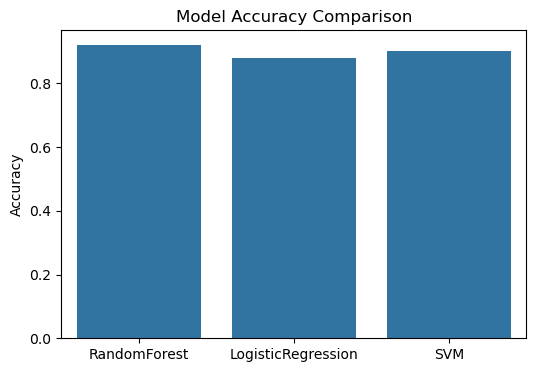

In [22]:
results = {
    "RandomForest": 0.92,
    "LogisticRegression": 0.88,
    "SVM": 0.90
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()